# Causal AI Fairness — Example 

In this notebook, we reproduce **Example** from the paper *Automatic Causal Fairness Analysis with LLM-Generated Reporting*.  
The goal is to demonstrate a compact end-to-end causal fairness analysis workflow.

In particular, we will:

- load a processed dataset
- define a Structural Fairness Model (SFM)
- fit a discrete Bayesian network
- compute observational and causal fairness effects
- inspect the distributions of the effects
- Report from the LLM given the results

## 1. Imports and repository setup

The cell below makes the notebook robust whether it is launched from the repository root or from the notebooks directory.

In [1]:
import sys
!{sys.executable} -m pip install daft-pgm

In [2]:
from pathlib import Path
import sys
import json
import os
import pandas as pd
from pgmpy.estimators import BayesianEstimator
from openai import OpenAI
from dotenv import load_dotenv
load_dotenv(override=True)  # loads OPENAI_API_KEY from .env

if os.getenv("OPENAI_API_KEY") is None:
    raise RuntimeError("OPENAI_API_KEY not found. ")

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

from src.effects import DE, IE, SE, TE, TV, effect_distribution, utility_weighted_effect
from src.graph import build_sfm
from src.model import fit_discrete_bayesian_model
from src.sym.dsl import Variable
from src.sym.effects import symbolic_NDE, symbolic_total_effect
from src.visualisation.graph import visualize_sfm
from src.llm import prepare_llm_payload_general, payload_to_json, summarize_with_llm_combined
REPO_ROOT

/Users/alessiaberarducci/Desktop/ale_causal-ai-fairness/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PosixPath('/Users/alessiaberarducci/Desktop/ale_causal-ai-fairness')

## 2. Load and prepare data

We reuse the processed Adult dataset and consider `education` as an ordered categorical variable in the discrete Bayesian network.

In [3]:
data_path = REPO_ROOT / "data" / "processed" / "berkeley_filtered.txt"
df = pd.read_csv(data_path)
selected_columns = [
    "Sex",
    "Admission",
    "Major",
]

df[selected_columns].head()


,Sex,Admission,Major
0,F,Rejected,C
1,M,Accepted,A
2,M,Rejected,C
3,M,Rejected,A
4,M,Accepted,A


In [4]:
df["Sex"].dtype
df["Sex"] = df["Sex"].astype("category")
df["Major"].dtype
df["Major"] = df["Major"].astype("category")
df["Admission"].dtype
df["Admission"] = df["Admission"].astype("category")

In [5]:
df[selected_columns].nunique().rename("cardinality")

Sex          2
Admission    2
Major        2
Name: cardinality, dtype: int64

## 3. Define the Structural Fairness Model

This graph encodes one sensitive attribute, one observed confounder, one mediator, and one outcome.

In [6]:
private_attr = "Sex"
outcome_attr = "Admission"
confounders = []
mediators = ["Major"]

sfm = build_sfm(
    sensitive_attr=private_attr,
    outcome_attr=outcome_attr,
    confounder_attrs=confounders,
    mediator_attrs=mediators,
)

sorted(sfm.edges())

[('Major', 'Admission'), ('Sex', 'Admission'), ('Sex', 'Major')]

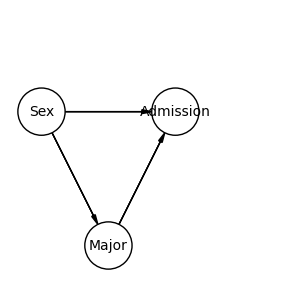

In [7]:
visualize_sfm(sfm)

## 4. Fit the Bayesian network

`fit_discrete_bayesian_model` keeps the SFM structure fixed and estimates the conditional distributions from the data.

In [8]:
bn = fit_discrete_bayesian_model(
    sfm=sfm,
    data=df[selected_columns],
    estimator_instance=(
        BayesianEstimator,
        {"prior_type": "dirichlet", "pseudo_counts": 1.0},
    ),
)

assert bn.check_model()
bn

2026-03-10 22:31:03.551 | DEBUG    | src.model:fit_discrete_bayesian_model:33 - Using estimator: <class 'pgmpy.estimators.BayesianEstimator.BayesianEstimator'> with parameters: {'prior_type': 'dirichlet', 'pseudo_counts': 1.0}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Sex': 'C', 'Admission': 'C', 'Major': 'C'}


In [9]:
variable_metadata= pd.Series(
    {node: bn.get_cpds(node).state_names[node] for node in bn.nodes}, name="states"
)

## 5. Compute core fairness effects

We evaluate the probability of the `Accepted` outcome when comparing `Female` to `Male`.

In [10]:
target = (outcome_attr, "Accepted")
x0 = "F"
x1 = "M"

results = pd.Series(
    {
        "TV": TV(bn, target, private_attr, x0, x1),
        "TE": TE(bn, target, private_attr, x0, x1),
        "SE(x0)": SE(bn, target, private_attr, x0),
        "SE(x1)": SE(bn, target, private_attr, x1),
        "NDE": DE(bn, target, private_attr, x0, x1),
        "NIE": IE(bn, target, private_attr, x1, x0),
    },
    name="effect",
)

results.round(4)

2026-03-10 22:31:03.566 | DEBUG    | src.effects:total_variation:247 - Computing total variation for target=('Admission', 'Accepted'), private_baseline=F, private_mod=M
2026-03-10 22:31:03.568 | DEBUG    | src.effects:spurious_effect:194 - Computing spurious effect for target=('Admission', 'Accepted'), private_value=F
2026-03-10 22:31:03.568 | DEBUG    | src.effects:spurious_effect:194 - Computing spurious effect for target=('Admission', 'Accepted'), private_value=M


TV        0.2320
TE        0.2320
SE(x0)    0.0000
SE(x1)    0.0000
NDE       0.0113
NIE      -0.2207
Name: effect, dtype: float64

## 6. Inspect full effect distributions

The library can return the full state-wise effect distribution for a target, not just a single state. That is useful when the target has multiple categories or when you want to define your own utility over outcomes.

In [11]:
target_states = bn.get_cpds(outcome_attr).state_names[outcome_attr]
te_distribution = effect_distribution(TE, bn, outcome_attr, private_attr, x0, x1)

pd.DataFrame({"state": target_states, "TE": te_distribution}).round(4)

,state,TE
0,Accepted,0.232
1,Rejected,-0.232


In [12]:
utility_map = {"Rejected": 0.0, "Accepted": 1.0}
utility_weighted_effect(TE, bn, outcome_attr, private_attr, x0, x1, utility_map)

0.23195325692719798

## 7. Symbolic expressions for the same causal quantities

The symbolic DSL is useful when you want to manipulate fairness queries before choosing a numerical estimator.

In [13]:
X = Variable(private_attr, (x0, x1))
Y = Variable(outcome_attr, tuple(target_states))
labels = bn.get_cpds(mediators[0]).state_names[mediators[0]]
W = Variable(mediators[0], tuple(labels))

symbolic_te = symbolic_total_effect(Y, "Accepted", X, x0, x1)
symbolic_nde = symbolic_NDE(Y, "Accepted", X, x0, x1, W)

symbolic_te


P(Event(Admission_{Sex='M'}='Accepted')) - P(Event(Admission_{Sex='F'}='Accepted'))

In [14]:
symbolic_nde

P(Event(Admission_{Major=Major_{Sex='F'}, Sex='M'}='Accepted')) - P(Event(Admission_{Sex='F'}='Accepted'))

## 8. Verify the decomposition identity

The decomposition tests in the suite verify the identity

$TV(x_0, x_1, y) = TE(x_0, x_1, y) + (SE(x_1, y) - SE(x_0, y))$.

Checking it directly in the notebook is a useful sanity test for a fitted model.

In [15]:
decomposition_check = pd.Series(
    {
        "TV": results["TV"],
        "TE + (SE(Fx1) - SE(x0))": results["TE"]
        + (results["SE(x1)"] - results["SE(x0)"]),
        "difference": results["TV"]
        - (results["TE"] + (results["SE(x1)"] - results["SE(x0)"])),
    },
)

decomposition_check.round(10)

TV                         0.231953
TE + (SE(Fx1) - SE(x0))    0.231953
difference                 0.000000
dtype: float64

The decomposition tests TE in the suite verify the identity

$TE(x_0, x_1, y) = NDE(x_0, x_1, y) - NIE(x_1,x_0,y)$.

In [16]:
decomposition_check_TE = pd.Series(
    {
        "TE": results["TE"],
        "NDE - NIE":  (results["NDE"] - results["NIE"]),
    },
)

decomposition_check_TE.round(10)

TE           0.231953
NDE - NIE    0.231953
dtype: float64

## 9. LLM report 

In [17]:
client = OpenAI()

In [18]:
state_names = {
    node: bn.get_cpds(node).state_names[node]
    for node in bn.nodes
    if bn.get_cpds(node) is not None
}

In [19]:
payload = prepare_llm_payload_general(
    dataset_name="Berkeley",
    X=private_attr,
    Y=outcome_attr,
    W=["Major"],
    Z=[],
    x0=x0,
    x1=x1,
    y_target=target,
    results=results.round(6),
    variable_metadata=variable_metadata,
    state_names=state_names,
    graph_edges=sorted(sfm.edges()),
    checks={
        "tv_decomposition": decomposition_check.round(10).to_dict(),
        "te_decomposition": decomposition_check_TE.round(10).to_dict(),
    },
)

In [20]:
payload_json = payload_to_json(payload)

In [21]:
text, latex_doc,token_usage = summarize_with_llm_combined(payload, client)

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"


In [22]:
print(latex_doc)

\documentclass{article}
\usepackage{geometry}
\geometry{margin=1in}
\usepackage{amsmath}
\begin{document}

\section*{Title: "Fairness Decomposition Report"}

\subsection*{Overview of the Fairness Analysis}
This analysis decomposes differences in the outcome Admission between groups $X=x0$ (F) and $X=x1$ (M) in the Berkeley dataset. The outcome $Y$ is Admission (Accepted vs.\ Rejected). The decomposition separates the total variation in Admission between sexes into direct, indirect (mediated by Major), and spurious components. The variables used include the mediator Major and no measured confounders.

\subsection*{Decomposition of Effects}
\begin{itemize}
  \item \textbf{Total variation (TV):} $0.2320$. This is the overall difference in Admission probability between M (x1) and F (x0); a positive value indicates higher Admission for M than for F.
  \item \textbf{Total effect (TE):} $0.2320$. The total causal effect of changing Sex from F to M on Admission is the same as TV here, indicati

In [23]:
token_usage

ResponseUsage(input_tokens=2043, input_tokens_details=InputTokensDetails(cached_tokens=0), output_tokens=2953, output_tokens_details=OutputTokensDetails(reasoning_tokens=1600), total_tokens=4996)